In [1]:
import matplotlib.pyplot as plt
from scipy import signal
import numpy as np
from adsp import adspfilter
plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)
def set_dark_style():
    plt.style.use("default")
    plt.rcParams.update({
        "figure.facecolor": "#000000",
        "axes.facecolor":   "#000000",
        "axes.edgecolor":   "#FFFFFF",
        "axes.labelcolor":  "#FFFFFF",
        "text.color":       "#FFFFFF",
        "xtick.color":      "#FFFFFF",
        "ytick.color":      "#FFFFFF",
        "grid.color":       "#444444",
        "legend.facecolor": "#000000",
        "legend.edgecolor": "#FFFFFF",
        "savefig.facecolor":"#000000",
        "savefig.edgecolor":"#000000",
    })
set_dark_style()

In [2]:
h_true = np.array([0.1, 0.3, 0.0, -0.2, -0.4, -0.7, -0.4, -0.2], dtype=np.float64)
M = len(h_true)

# ==============================================================
# AR(1) generator with target eigenvalue spread
# ==============================================================
def ar1Input(a, N, sigma_v2=1.0):
  v = np.sqrt(sigma_v2) * np.random.randn(N)
  x = np.zeros(N)
  for n in range(1, N):
    x[n] = a * x[n-1] + v[n]
  x /= np.std(x)
  return x

In [3]:
def runSysID(
    model,
    spread=20,
    N=1000,
    sigma_n2=1e-4,
    n_runs=200,
    burnin=2000,
):
  """
  Monte-Carlo averaged MSE learning curve
  """
  a = adspfilter.ar1poleSpreadSearch(spread, M)

  # determine output length dynamically
  x_test = ar1Input(a, N + M)
  d_test = np.convolve(x_test, h_true)[:N]
  model.w = np.zeros(M)
  _, e_test, _ = model(x_test[:N], d_test, train=False)
  out_len = len(e_test)

  mse_runs = np.zeros((n_runs, out_len))

  for r in range(n_runs):
    x = ar1Input(a, N + M)        
    noise = np.sqrt(sigma_n2) * np.random.randn(N)
    d = np.convolve(x, h_true)[:N] + noise
    model.w = np.zeros(M)                      # reset weights
    y, e, _ = model(x[:N], d, train=True)
    mse_runs[r] = np.abs(e)**2

  mse_avg = np.mean(mse_runs, axis=0)
  burn = min(burnin, out_len // 2)
  misadj = (np.mean(mse_avg[burn:]) - sigma_n2) / sigma_n2

  return mse_avg, misadj

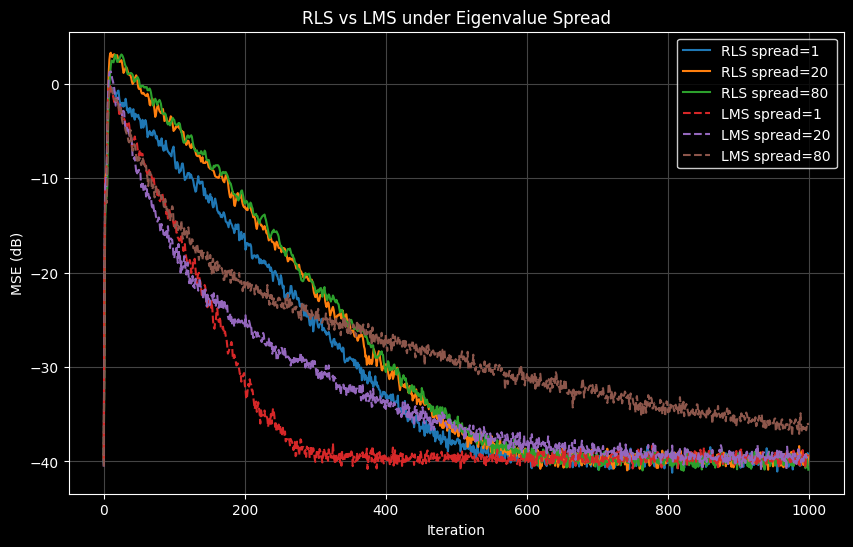

In [6]:
# RLS
rls = adspfilter.RLS(lam=0.99, mu=None, delta=1e-2, filter_order=M-1)
mse_r1, _ = runSysID(rls, spread=1)
mse_r20, _ = runSysID(rls, spread=20)
mse_r80, _ = runSysID(rls, spread=80)

# LMS
lms = adspfilter.LMS(mu=0.01, filter_order=M-1)
mse_l1, _ = runSysID(lms, spread=1)
mse_l20, _ = runSysID(lms, spread=20)
mse_l80, _ = runSysID(lms, spread=80)

plt.figure(figsize=(10,6))

# RLS
plt.plot(10*np.log10(mse_r1), label="RLS spread=1")
plt.plot(10*np.log10(mse_r20), label="RLS spread=20")
plt.plot(10*np.log10(mse_r80), label="RLS spread=80")

# LMS
plt.plot(10*np.log10(mse_l1), '--', label="LMS spread=1")
plt.plot(10*np.log10(mse_l20), '--', label="LMS spread=20")
plt.plot(10*np.log10(mse_l80), '--', label="LMS spread=80")

plt.legend()
plt.grid()
plt.title("RLS vs LMS under Eigenvalue Spread")
plt.xlabel("Iteration")
plt.ylabel("MSE (dB)")
plt.show()